In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()   # Load the CIFAR-10 dataset
X_train.shape

(50000, 32, 32, 3)

In [3]:
X_test.shape  # Check the shape of the test set

(10000, 32, 32, 3)

In [4]:
y_train.shape

(50000, 1)

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [6]:
y_train = y_train.reshape(-1,)    # Reshape y_train to be a 1D array
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [7]:
y_test = y_test.reshape(-1,)     # Reshape y_test to be a 1D array

In [8]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [9]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))             # Set the figure size
    plt.imshow(X[index])                     # Display the image at the specified index
    plt.xlabel(classes[y[index]])            # Set the x-axis label to the class name

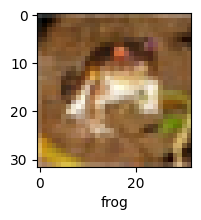

In [10]:
plot_sample(X_train, y_train, 0)

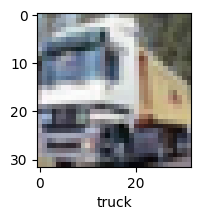

In [11]:
plot_sample(X_train, y_train, 1)

In [12]:
X_train = X_train / 255.0    # Normalize the data
X_test = X_test / 255.0

In [13]:
cnn = models.Sequential([       # Create a Sequential model
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),    # First convolutional layer
    layers.MaxPooling2D((2, 2)),                                                                  # First max pooling layer
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),           # Second convolutional layer
    layers.MaxPooling2D((2, 2)),                                                # Second max pooling layer
    
    layers.Flatten(),                                   # Flatten the output      
    layers.Dense(64, activation='relu'),                # Fully connected layer
    layers.Dense(10, activation='softmax')              # Output layer with softmax activation for multi-class classification
])

c:\Users\phane\OneDrive\Documents\Collge Internship Work (NITPY)\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
cnn.compile(optimizer='adam',                           # Compile the model
              loss='sparse_categorical_crossentropy',   # Loss function for multi-class classification
              metrics=['accuracy'])                     # Metric to monitor

In [15]:
cnn.fit(X_train, y_train, epochs=10)            # Train the model for 10 epochs

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4652 - loss: 1.4851
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6012 - loss: 1.1383
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6484 - loss: 1.0107
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6767 - loss: 0.9297
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6966 - loss: 0.8776
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7137 - loss: 0.8273
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7305 - loss: 0.7792
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.7415 - loss: 0.7430
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7535 - loss: 0.7075
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7648 - loss: 0.6758


In [16]:
cnn.evaluate(X_test,y_test)                 # Evaluate the model on the test set

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6928 - loss: 0.9184


[0.9184163212776184, 0.692799985408783]

In [17]:
y_pred = cnn.predict(X_test)                # Predict the classes for the test set
y_pred[:5]                                  # Display the first 5 predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[1.17916719e-03, 1.85595884e-04, 1.67163881e-03, 9.25862908e-01,
        8.86477937e-04, 1.67829171e-02, 2.63967533e-02, 1.21566525e-04,
        2.59355959e-02, 9.77394520e-04],
       [2.93202642e-02, 6.50602356e-02, 4.09183167e-06, 2.23863094e-06,
        4.09568713e-07, 5.00994474e-07, 4.71162132e-09, 4.27262759e-09,
        8.99412870e-01, 6.19941996e-03],
       [2.17718463e-02, 6.00817837e-02, 3.16883699e-04, 2.22647656e-03,
        7.04026534e-05, 1.33838708e-04, 3.12876764e-05, 3.85372041e-05,
        9.05016243e-01, 1.03126597e-02],
       [9.62595403e-01, 2.46182224e-03, 6.57419348e-03, 2.62960466e-03,
        2.11479329e-03, 1.68750732e-04, 1.83087774e-04, 2.91558281e-05,
        2.31558885e-02, 8.71467273e-05],
       [1.76012429e-06, 1.63505421e-04, 6.95765764e-03, 4.40708585e-02,
        1.62095070e-01, 1.77786092e-03, 7.84822762e-01, 3.93480623e-05,
        6.73075192e-05, 3.88372973e-06]], dtype=float32)

In [18]:
y_classes = [np.argmax(element) for element in y_pred]  # Convert predictions to class labels
y_classes[:5]                                           # Display the first 5 class labels

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [19]:
y_test[:5]                                  # Display the first 5 true labels

array([3, 8, 8, 0, 6], dtype=uint8)

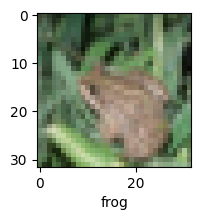

In [20]:
plot_sample(X_test, y_test,4)                       # Plot the 5th test image with its true label

In [21]:
classes[y_classes[4]]   # Display the predicted class for the 5th test image                        

'frog'

In [22]:
import random

def predict_random_image(model, X, y, classes):
    # Pick a random index
    idx = random.randint(0, len(X)-1)
    
    # Get image and label
    img = X[idx]
    true_label = y[idx]
    
    # Model expects batch → expand dims
    img_batch = np.expand_dims(img, axis=0)
    
    # Predict
    pred = model.predict(img_batch)
    pred_class = np.argmax(pred[0])
    
    # Show image with labels
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {classes[pred_class]} | True: {classes[true_label]}")
    plt.show()
    
    return classes[pred_class], classes[true_label]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


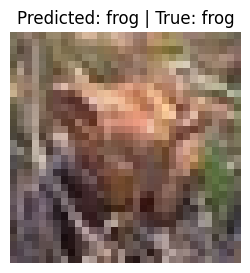

Model predicted: frog | Actual: frog


In [28]:
pred, true = predict_random_image(cnn, X_test, y_test, classes)                 # Predict a random image from the test set
print("Model predicted:", pred, "| Actual:", true)                              # Print the predicted and actual class names

In [29]:
%pip install scikit-learn
from sklearn.metrics import confusion_matrix, classification_report

Note: you may need to restart the kernel to use updated packages.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
 [[784  32  40   6  15   4  13  15  45  46]
 [ 18 840  11  10   3   3   5   4  13  93]
 [ 75  11 585  40  91  55  77  40  11  15]
 [ 36  20  91 453  70 150  95  43  22  20]
 [ 32  10  81  54 622  22  91  71  12   5]
 [ 16   8  75 162  53 543  55  60  14  14]
 [  9  10  67  39  29  23 798   3  11  11]
 [ 14   3  46  14  69  38  12 765   5  34]
 [ 77  57  24   7  10   6   8  11 764  36]
 [ 35  88   8   9   7   5   8  16  13 811]]


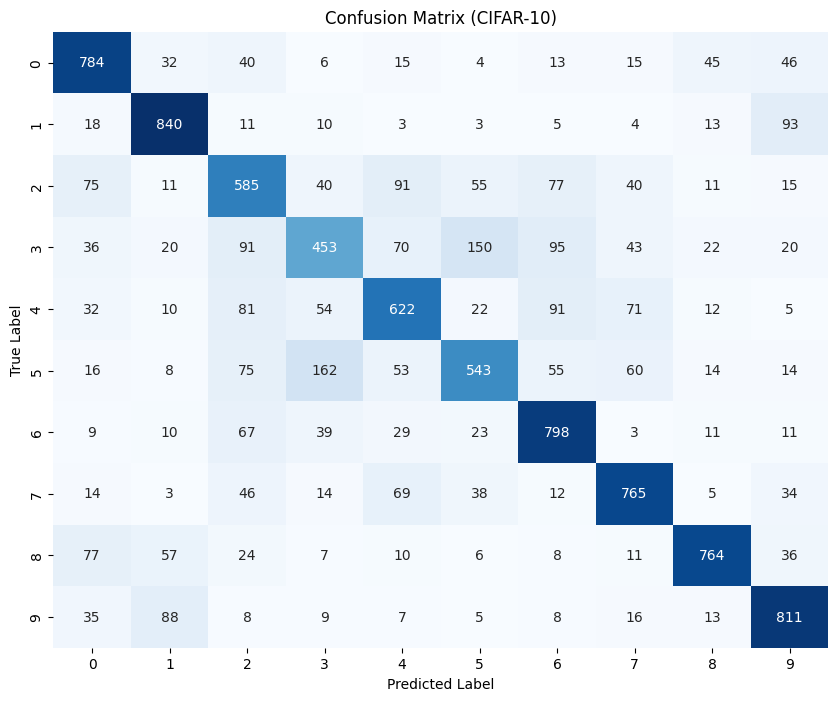


Per-Class TP / FP / FN / TN:
Class 0: TP=784, FP=312, FN=216, TN=8688
Class 1: TP=840, FP=239, FN=160, TN=8761
Class 2: TP=585, FP=443, FN=415, TN=8557
Class 3: TP=453, FP=341, FN=547, TN=8659
Class 4: TP=622, FP=347, FN=378, TN=8653
Class 5: TP=543, FP=306, FN=457, TN=8694
Class 6: TP=798, FP=364, FN=202, TN=8636
Class 7: TP=765, FP=263, FN=235, TN=8737
Class 8: TP=764, FP=146, FN=236, TN=8854
Class 9: TP=811, FP=274, FN=189, TN=8726

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.78      0.75      1000
           1       0.78      0.84      0.81      1000
           2       0.57      0.58      0.58      1000
           3       0.57      0.45      0.51      1000
           4       0.64      0.62      0.63      1000
           5       0.64      0.54      0.59      1000
           6       0.69      0.80      0.74      1000
           7       0.74      0.77      0.75      1000
           8       0.84      0.76      0.80     

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions
y_pred = cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)   # predicted class indices
y_true = y_test.astype(int)                  # true labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (CIFAR-10)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Calculate TP, FP, FN, TN for each class
print("\nPer-Class TP / FP / FN / TN:")
for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    print(f"Class {i}: TP={TP}, FP={FP}, FN={FN}, TN={TN}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))
